In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

folder_path = "/content/drive/MyDrive/processed_cai_images"

In [3]:
files = os.listdir(folder_path)
print(len(files))

for i in range(10):
    print(files[i])

800
c8-50_back.jpg
mask_c8-50_back.jpg
mask_q24-2_back.jpg
q24-2_back.jpg
mask_c24-45_front.jpg
c24-45_front.jpg
r45-10_back.jpg
mask_r45-10_back.jpg
mask_c24-13_back.jpg
c24-13_back.jpg


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

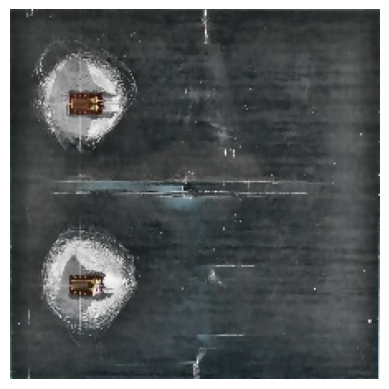

In [4]:
import cv2
import matplotlib.pyplot as plt

img_path = os.path.join(folder_path, files[0])
img = cv2.imread(img_path)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

In [5]:
import numpy as np
images = []
labels = []

for file in os.listdir(folder_path):
    path = os.path.join(folder_path, file)

    img = cv2.imread(path)
    img = cv2.resize(img, (224, 224))

    images.append(img)

images = np.array(images)
print(images.shape)

(800, 224, 224, 3)


In [6]:
image_files = [f for f in files if not f.startswith("mask")]
mask_files = [f for f in files if f.startswith("mask")]

image_files.sort()
mask_files.sort()

pairs = list(zip(image_files, mask_files))

print(pairs[:5])

[('c16-10_front.jpg', 'mask_c16-10_front.jpg'), ('c16-11_back.jpg', 'mask_c16-11_back.jpg'), ('c16-11_front.jpg', 'mask_c16-11_front.jpg'), ('c16-12_back.jpg', 'mask_c16-12_back.jpg'), ('c16-12_front.jpg', 'mask_c16-12_front.jpg')]


In [7]:
X = []
Y = []

for img_file, mask_file in pairs:
    img = cv2.imread(os.path.join(folder_path, img_file))
    mask = cv2.imread(os.path.join(folder_path, mask_file), 0)

    img = cv2.resize(img, (224, 224))
    mask = cv2.resize(mask, (224, 224))

    X.append(img)
    Y.append(mask)

X = np.array(X)
Y = np.array(Y)

print(X.shape, Y.shape)

(400, 224, 224, 3) (400, 224, 224)


In [8]:
import os
import numpy as np
from sklearn.model_selection import train_test_split

folder = "/content/drive/MyDrive/processed_cai_images"

files = os.listdir(folder)

images = sorted([f for f in files if not f.startswith("mask")])
masks = sorted([f for f in files if f.startswith("mask")])

pairs = list(zip(images, masks))

train, temp = train_test_split(pairs, test_size=0.3, random_state=42)
val, test = train_test_split(temp, test_size=0.5, random_state=42)

print(len(train), len(val), len(test))

280 60 60


In [9]:
import cv2

IMG_SIZE = 224

def load_data(pairs):
    X, Y = [], []

    for img_file, mask_file in pairs:
        img = cv2.imread(os.path.join(folder, img_file))
        mask = cv2.imread(os.path.join(folder, mask_file), 0)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE)) / 255.0

        mask = np.expand_dims(mask, axis=-1)

        X.append(img)
        Y.append(mask)

    return np.array(X), np.array(Y)

X_train, Y_train = load_data(train)
X_val, Y_val = load_data(val)
X_test, Y_test = load_data(test)

In [10]:
from tensorflow.keras.layers import *

def channel_attention(x, ratio=8):
    channel = x.shape[-1]

    avg_pool = GlobalAveragePooling2D()(x)
    max_pool = GlobalMaxPooling2D()(x)

    dense = Dense(channel // ratio, activation='relu')

    avg_out = dense(avg_pool)
    max_out = dense(max_pool)

    out = Add()([avg_out, max_out])
    out = Dense(channel, activation='sigmoid')(out)

    out = Reshape((1,1,channel))(out)
    return Multiply()([x, out])

In [11]:
def spatial_attention(x):
    avg_pool = Lambda(lambda x: np.mean(x, axis=-1, keepdims=True))(x)
    max_pool = Lambda(lambda x: np.max(x, axis=-1, keepdims=True))(x)

    concat = Concatenate(axis=-1)([avg_pool, max_pool])
    out = Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)

    return Multiply()([x, out])

In [12]:
def hybrid_attention(x):
    x = channel_attention(x)
    x = spatial_attention(x)
    return x

In [13]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
import tensorflow as tf

def channel_attention(x, ratio=8):
    channel = x.shape[-1]

    avg_pool = GlobalAveragePooling2D()(x)
    max_pool = GlobalMaxPooling2D()(x)

    dense = Dense(channel // ratio, activation='relu')

    avg_out = dense(avg_pool)
    max_out = dense(max_pool)

    out = Add()([avg_out, max_out])
    out = Dense(channel, activation='sigmoid')(out)

    out = Reshape((1,1,channel))(out)
    return Multiply()([x, out])

def spatial_attention(x):
    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(x)
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(x)

    concat = Concatenate(axis=-1)([avg_pool, max_pool])
    out = Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)

    return Multiply()([x, out])

def hybrid_attention(x):
    x = channel_attention(x)
    x = spatial_attention(x)
    return x

def conv_block(x, filters):
    x = Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = hybrid_attention(x)
    return x

def build_model():
    inputs = Input((224,224,3))

    c1 = conv_block(inputs, 32)
    p1 = MaxPooling2D()(c1)

    c2 = conv_block(p1, 64)
    p2 = MaxPooling2D()(c2)

    c3 = conv_block(p2, 128)
    p3 = MaxPooling2D()(c3)

    c4 = conv_block(p3, 256)

    u1 = UpSampling2D()(c4)
    u1 = Concatenate()([u1, c3])
    c5 = conv_block(u1, 128)

    u2 = UpSampling2D()(c5)
    u2 = Concatenate()([u2, c2])
    c6 = conv_block(u2, 64)

    u3 = UpSampling2D()(c6)
    u3 = Concatenate()([u3, c1])
    c7 = conv_block(u3, 32)

    outputs = Conv2D(1, 1, activation='sigmoid')(c7)

    return Model(inputs, outputs)

model = build_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 224, 224,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv2d_1[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 32)        │          0 │ conv2d_1[0][0]    │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │        132 │ global_average_p… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 4)         │          0 │ dense[0][0],      │
│                     │                   │            │ dense[1][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        160 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 32)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 224, 224,  │          0 │ conv2d_1[0][0],   │
│                     │ 32)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 224, 224,  │          0 │ multiply[0][0]    │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 224, 224,  │          0 │ multiply[0][0]    │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 224, 224,  │          0 │ lambda[0][0],     │
│ (Concatenate)       │ 2)                │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 224, 224,  │         99 │ concatenate[0][0] │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 224, 224,  │          0 │ multiply[0][0],   │
│ (Multiply)          │ 32)               │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ multiply_1[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,975,502 (7.54 MB)

 Trainable params: 1,975,502 (7.54 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=20,
    batch_size=8
)

Epoch 1/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 54s 443ms/step - accuracy: 0.7650 - loss: 0.5492 - val_accuracy: 0.7945 - val_loss: 0.3759
Epoch 2/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - accuracy: 0.7698 - loss: 0.3552 - val_accuracy: 0.7945 - val_loss: 0.2590
Epoch 3/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 132ms/step - accuracy: 0.7844 - loss: 0.2866 - val_accuracy: 0.7838 - val_loss: 0.3592
Epoch 4/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step - accuracy: 0.8028 - loss: 0.2682 - val_accuracy: 0.8398 - val_loss: 0.1963
Epoch 5/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 132ms/step - accuracy: 0.8173 - loss: 0.1966 - val_accuracy: 0.8404 - val_loss: 0.1428
Epoch 6/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 136ms/step - accuracy: 0.8241 - loss: 0.1673 - val_accuracy: 0.8492 - val_loss: 0.1244
Epoch 7/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 135ms/step - accuracy: 0.8294 - loss: 0.1538 - val_accuracy: 0.8532 - val_loss: 0.1130
Epoch 8/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 137ms/step - accuracy: 0.8313 - loss: 0.1467 - val_accuracy: 0

In [16]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=10,
    batch_size=8
)

Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 38s 344ms/step - accuracy: 0.8470 - loss: 0.0926 - val_accuracy: 0.8584 - val_loss: 0.0923
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 134ms/step - accuracy: 0.8479 - loss: 0.0904 - val_accuracy: 0.8579 - val_loss: 0.0927
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 134ms/step - accuracy: 0.8483 - loss: 0.0894 - val_accuracy: 0.8580 - val_loss: 0.0927
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 138ms/step - accuracy: 0.8486 - loss: 0.0887 - val_accuracy: 0.8579 - val_loss: 0.0928
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 134ms/step - accuracy: 0.8489 - loss: 0.0881 - val_accuracy: 0.8579 - val_loss: 0.0927
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 133ms/step - accuracy: 0.8491 - loss: 0.0876 - val_accuracy: 0.8579 - val_loss: 0.0924
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 137ms/step - accuracy: 0.8493 - loss: 0.0871 - val_accuracy: 0.8579 - val_loss: 0.0924
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 133ms/step - accuracy: 0.8494 - loss: 0.0868 - val_accuracy: 0

In [17]:
loss, acc = model.evaluate(X_test, Y_test)
print("Test Accuracy:", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 27s 13s/step - accuracy: 0.8476 - loss: 0.1019
Test Accuracy: 0.8475891947746277


In [18]:
y_pred = model.predict(X_test)
y_pred_bin = (y_pred > 0.5).astype(np.float32)

2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step


In [19]:
import numpy as np

def dice_score(y_true, y_pred):
    smooth = 1e-6
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    return (2 * np.sum(y_true_f * y_pred_f) + smooth) / (np.sum(y_true_f) + np.sum(y_pred_f) + smooth)

def iou_score(y_true, y_pred):
    smooth = 1e-6
    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

def precision(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    return tp / (tp + fp + 1e-6)

def recall(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp / (tp + fn + 1e-6)

def r2_score(y_true, y_pred):
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    ss_res = np.sum((y_true_f - y_pred_f)**2)
    ss_tot = np.sum((y_true_f - np.mean(y_true_f))**2)
    return 1 - (ss_res / (ss_tot + 1e-6))

In [20]:
dice = dice_score(Y_test, y_pred_bin)
iou = iou_score(Y_test, y_pred_bin)
prec = precision(Y_test, y_pred_bin)
rec = recall(Y_test, y_pred_bin)
f1 = 2 * (prec * rec) / (prec + rec + 1e-6)
r2 = r2_score(Y_test, y_pred)

print("Dice:", dice)
print("IoU:", iou)
print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1)
print("R2:", r2)

Dice: 0.9760842048315449
IoU: 0.9532856211784172
Precision: 0.9877196888814345
Recall: 0.9837406977519524
F1: 0.9857256779275217
R2: 0.7555619869144122


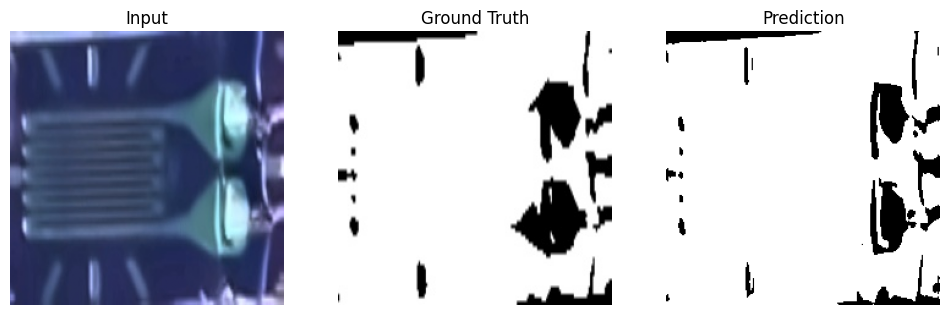

In [21]:
import random

idx = random.randint(0, len(X_test)-1)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(X_test[idx])
plt.title("Input")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(Y_test[idx].squeeze(), cmap='gray')
plt.title("Ground Truth")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(y_pred_bin[idx].squeeze(), cmap='gray')
plt.title("Prediction")
plt.axis('off')

plt.show()

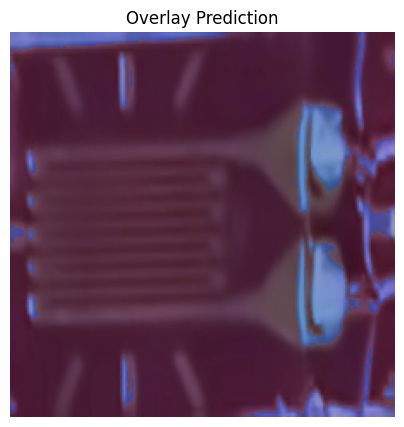

In [22]:
plt.figure(figsize=(5,5))
plt.imshow(X_test[idx])
plt.imshow(y_pred_bin[idx].squeeze(), cmap='jet', alpha=0.4)
plt.title("Overlay Prediction")
plt.axis('off')
plt.show()

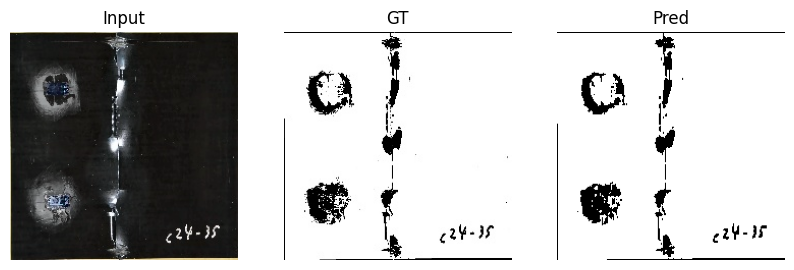

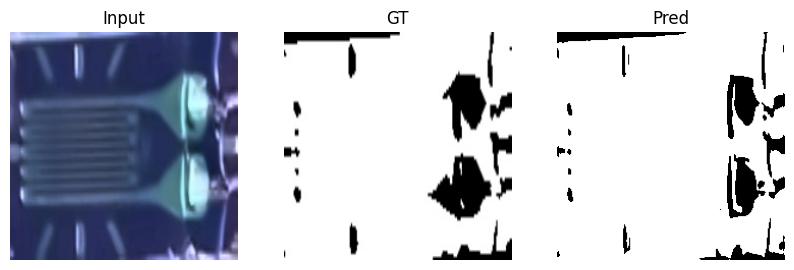

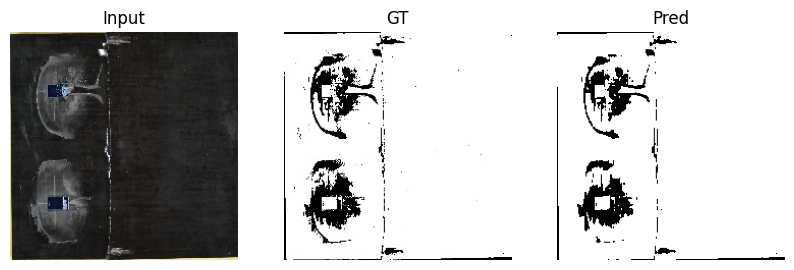

In [23]:
for i in range(3):
    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.imshow(X_test[i])
    plt.title("Input")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(Y_test[i].squeeze(), cmap='gray')
    plt.title("GT")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(y_pred_bin[i].squeeze(), cmap='gray')
    plt.title("Pred")
    plt.axis('off')

    plt.show()

In [24]:
for layer in model.layers[::-1]:
    if "conv" in layer.name:
        print(layer.name)
        break

conv2d_21


In [25]:
import tensorflow as tf
import numpy as np
import cv2

def grad_cam(model, image, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    image = np.expand_dims(image, axis=0)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image)
        loss = tf.reduce_mean(predictions)

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0) / (np.max(heatmap) + 1e-6)

    return heatmap.numpy()

In [30]:
idx = 0
image = X_test[idx]

import tensorflow as tf
import numpy as np
import cv2

def grad_cam(model, image, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    image_tensor = tf.convert_to_tensor(np.expand_dims(image, axis=0), dtype=tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image_tensor)
        loss = tf.reduce_mean(predictions)

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Use TensorFlow operations for maximum and reduction
    heatmap = tf.maximum(heatmap, 0.0) / (tf.reduce_max(heatmap) + 1e-6)

    return heatmap.numpy()

heatmap = grad_cam(model, image, "conv2d_21")

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)


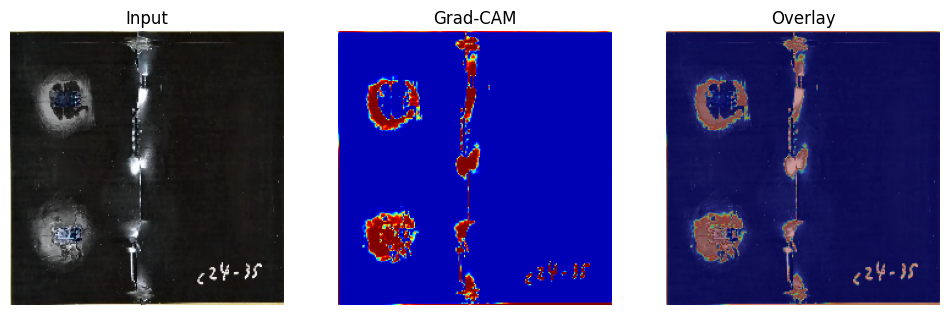

In [31]:
heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

overlay = cv2.addWeighted(
    (image*255).astype(np.uint8),
    0.6,
    heatmap,
    0.4,
    0
)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Input")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(heatmap)
plt.title("Grad-CAM")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis('off')

plt.show()

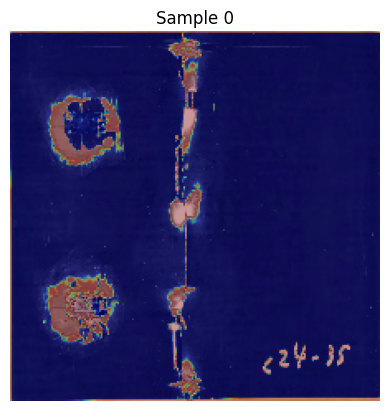

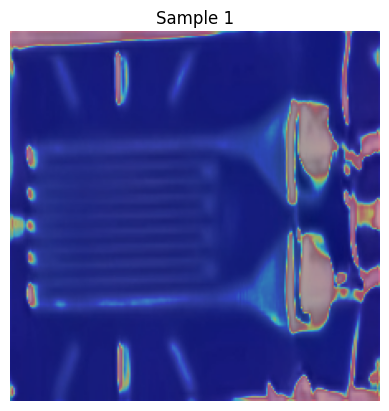

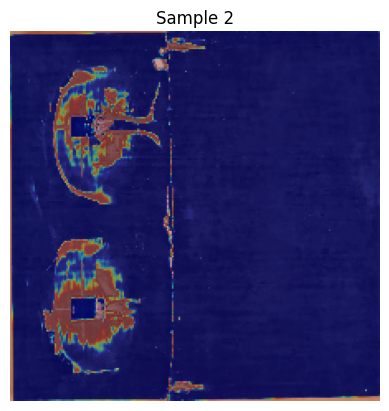

In [33]:
for i in range(3):
    heatmap = grad_cam(model, X_test[i], "conv2d_21")

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(
        (X_test[i]*255).astype(np.uint8),
        0.6,
        heatmap,
        0.4,
        0
    )

    plt.imshow(overlay)
    plt.title(f"Sample {i}")
    plt.axis('off')
    plt.show()